This notebook will walk you through how to gather Capacity Factor data (CF) for solar and wind generation in a zone of intrest!

I will be walking through the example of the Midcontinent Independent System Operator (MISO) region between 2020 and 2024, but will point out where you should make your changes to adapt this to your region and time range of intrest

Step 0:
Download the following required libraries

In [1]:
pip install atlite rasterio geopandas cartopy matplotlib numpy xarray

Note: you may need to restart the kernel to use updated packages.


Step 1:
Import the weather data for your rough area of intrest (a big square that we will later cut out to our actual area of intrest)

Modify the following lines to your projects intrests:

for year in [2020, 2021, 2022, 2023, 2024]: (change to the years that intrest you)

x=slice(-105, -82), (Change to the Latitude and Longitude points of the top left corner)
y=slice(28, 50), (Change to the Latitude and Longitude points of the bottem right corner)

These are heavy files, and this could take hours to download (about 10 mins per file), so consider letting this run overnight.

In [ ]:
import atlite

for year in [2020, 2021, 2022, 2023, 2024]:
    for month in range(1,13):
        month_str = f"{month:02d}"
        import calendar
        last_day = calendar.monthrange(year, month)[1]
        
        path = f"weather-data-{year}-{month_str}.nc"
        
        cutout = atlite.Cutout(
            path=path,
            module="era5",
            x=slice(-105, -82),
            y=slice(28, 50),
            time=slice(f"{year}-{month_str}-01", f"{year}-{month_str}-{last_day}"),
        )
        cutout.prepare(features=["wind", "influx", "height", "temperature"])
        print(f"Done: {year}-{month_str}")

Step 2: Merge all the individual weather files into one large file

This step will skip any file that is empty in the event it downloaded wrong

In [62]:
import xarray as xr
import os

#data_dir = "/Users/mshaaban/Miso_Weather_Data"
data_dir = "/Users/mshaaban"


datasets = []
for year in [2020, 2021, 2022, 2023, 2024]: # Change the years as needed
        path = os.path.join(data_dir, f"miso-{year}.nc")
        if os.path.exists(path):
            datasets.append(xr.open_dataset(path))
        else:
            print(f"Skipping missing file: {path}")

combined = xr.concat(datasets, dim="time")
print(combined)

<xarray.Dataset> Size: 22GB
Dimensions:               (x: 93, y: 89, time: 43848)
Coordinates:
  * x                     (x) float64 744B -105.0 -104.8 -104.5 ... -82.25 -82.0
  * y                     (y) float64 712B 28.0 28.25 28.5 ... 49.5 49.75 50.0
  * time                  (time) datetime64[ns] 351kB 2020-01-01 ... 2024-12-...
    lon                   (x) float64 744B -105.0 -104.8 -104.5 ... -82.25 -82.0
    lat                   (y) float64 712B 28.0 28.25 28.5 ... 49.5 49.75 50.0
Data variables: (12/13)
    wnd100m               (time, y, x) float32 1GB 4.712 5.511 ... 4.727 4.725
    wnd_azimuth           (time, y, x) float32 1GB 5.441 5.302 ... 1.385 1.371
    roughness             (time, y, x) float32 1GB 0.02124 0.02124 ... 1.767
    influx_toa            (time, y, x) float32 1GB 191.1 186.6 182.0 ... 0.0 0.0
    influx_direct         (time, y, x) float32 1GB 54.01 46.63 38.84 ... 0.0 0.0
    influx_diffuse        (time, y, x) float32 1GB 44.3 44.94 45.12 ... 0.0 0.0
   

Then, once it is all comebined, save the file to your device
The last portion of the path in the first line can be named whatever you desire,
It is called combined_weather_data for now

In [64]:
combined.to_netcdf("/Users/mshaaban/weather_data_2020-2024.nc")
print("Saved.")

Saved.


Lastly is to reload the combined file as a cutout

In [66]:
import atlite

combined_path = "/Users/mshaaban/weather_data_2020-2024.nc"
# Example: "/Users/mshaaban/Miso_Weather_Data/combined_weather_data.nc"

cutout = atlite.Cutout(path=combined_path)
print(cutout)
print(f"Time range: {cutout.coords['time'].values[0]} to {cutout.coords['time'].values[-1]}")
print(f"Spatial extent: x={cutout.coords['x'].values[[0,-1]]}, y={cutout.coords['y'].values[[0,-1]]}")

<Cutout "weather_data_2020-2024">
 x = -105.00 ⟷ -82.00, dx = 0.25
 y = 28.00 ⟷ 50.00, dy = 0.25
 time = 2020-01-01 ⟷ 2024-12-31, dt = h
 module = era5
 prepared_features = ['wind', 'influx', 'height', 'temperature']
Time range: 2020-01-01T00:00:00.000000000 to 2024-12-31T23:00:00.000000000
Spatial extent: x=[-105.  -82.], y=[28. 50.]


Step 3: Load in the shape file for your region, ideally a .geojson file

Cordinate Referance System (CRS) is an important value for atlite for area calculations. using the right CRS for your area matters alot. Here are some CRS EPSGs for key areas:

Contiguous US: 5070
Europe: 3035
Australia: 3577
Middle East & Asia: 32638
Africa: 203033
North America (in full): 102008

EPSG:5070
(1, 7)


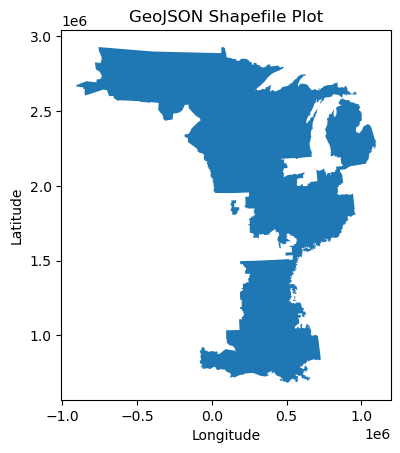

In [70]:
import requests
import geopandas as gpd
import matplotlib.pyplot as plt

# These next few lines are to get the shapefile data from 
# the arcgis website and save it as a geojson file. 
# You can skip this step if you already have a geojson file for your respective region.
#url = "Enter the URL to the arcgis website here, for example: https://services1.arcgis.com/0MSEUqKaxRlEPj5P/arcgis/rest/services/MISO_Boundary/FeatureServer/0/query?where=1%3D1&outFields=*&outSR=4326&f=geojson"
##r = requests.get(url)
#with open("Enter the path to save the geojson file here", "wb") as f:
   # f.write(r.content)
# Here is an example of the path to save the geojson file: 
# "/Users/mshaaban/Miso_Weather_Data/miso_boundary.geojson"
# The last part of the path (miso_boundary.geojson) is the name of the geojson file. 
# You can change it as needed (ie, call your geojson file whatever you desire).

miso = gpd.read_file("miso_shapefile.geojson") # Change the path to your geojson file as needed
miso = miso.to_crs("5070") 

print(miso.crs)
print(miso.shape)
miso.plot()
plt.title("GeoJSON Shapefile Plot")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

Step 4: Build an availability matrix.

In [72]:
import geopandas as gpd
import atlite
from atlite.gis import ExclusionContainer

miso = gpd.read_file("miso_shapefile.geojson") # Change the path to your geojson file as needed
miso = miso.to_crs("5070").geometry

excluder = ExclusionContainer(crs=5070, res=1000)

A = cutout.availabilitymatrix(miso, excluder)
print(A)

<xarray.DataArray (dim_0: 1, y: 89, x: 93)> Size: 66kB
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]])
Coordinates:
  * dim_0    (dim_0) int64 8B 0
  * y        (y) float64 712B 28.0 28.25 28.5 28.75 ... 49.25 49.5 49.75 50.0
  * x        (x) float64 744B -105.0 -104.8 -104.5 -104.2 ... -82.5 -82.25 -82.0


Step 5: Build capacity matrix:

In [73]:
import xarray as xr

area = cutout.grid.set_index(["y", "x"]).to_crs(5070).area / 1e6  # km²
area = xr.DataArray(area, dims=("spatial",))

capacity_matrix_wind  = A.stack(spatial=["y", "x"]) * area * 2   # MW/km²
capacity_matrix_solar = A.stack(spatial=["y", "x"]) * area * 40  # MW/km²

Step 6: Calculate the CF

In [74]:
# Wind
wind_cf = cutout.wind(
    matrix=capacity_matrix_wind,
    turbine="Vestas_V90_3MW",
    index=miso.index,
    per_unit=True
)
print("Wind done")

# Solar
solar_cf = cutout.pv(
    panel="CSi",
    orientation={"slope": 30.0, "azimuth": 180.0},
    matrix=capacity_matrix_solar,
    index=miso.index,
    per_unit=True
)
print("Solar done")

/opt/anaconda3/envs/table_pypsa_env/lib/python3.10/site-packages/atlite/resource.py:72: FutureWarning: 'add_cutout_windspeed' for wind turbine
power curves will default to True in atlite relase v0.2.15.
  warnings.warn(msg, FutureWarning)
INFO:atlite.convert:Convert and aggregate 'wind'.
INFO:atlite.convert:Convert and aggregate 'pv'.


Wind done
Solar done


Step 7: Save the calculated CF to a file on your computer

Once again, change the path to your desired file path and name

In [75]:
wind_cf.to_netcdf("/Users/mshaaban/miso_wind_cf_2020-2024.nc")
solar_cf.to_netcdf("/Users/mshaaban/miso_solar_cf_2020-2024.nc")
print("Saved.")

Saved.


The code below converts .nc files to .csv files which makes it easier to inspect the data you have

In [77]:
import xarray as xr
import pandas as pd
data = xr.open_dataarray('/Users/mshaaban/miso_solar_cf_2020-2024.nc')

df = data.to_series().reset_index()
df.columns = ['time', 'Spatial', 'capacity_factor']  # Rename columns as needed

df.to_csv("/Users/mshaaban/miso_solar_cf_2020-2024.csv", index=False)
print("Saved to CSV.")

Saved to CSV.


In [41]:
import xarray as xr
import pandas as pd
data = xr.open_dataset('/Users/mshaaban/miso_wind_cf_2020_test.nc')
print(data['time'])

<xarray.DataArray 'time' (time: 8784)> Size: 70kB
array(['2020-01-01T00:00:00.000000000', '2020-01-01T01:00:00.000000000',
       '2020-01-01T02:00:00.000000000', ..., '2020-12-31T21:00:00.000000000',
       '2020-12-31T22:00:00.000000000', '2020-12-31T23:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 70kB 2020-01-01 ... 2020-12-31T23:00:00


In [46]:
import atlite
import logging
logging.basicConfig(level=logging.INFO)

for year in [2022, 2023, 2024]:
    path = f"miso-{year}.nc"
    cutout = atlite.Cutout(
        path=path,
        module="era5",
        x=slice(-105, -82),
        y=slice(28, 50),
        time=slice(f"{year}-01-01", f"{year}-12-31"),
    )
    cutout.prepare(
        features=["wind", "influx", "height", "temperature"],
        monthly_requests=True,      # breaks the year into monthly CDS requests
        concurrent_requests=True,   # posts all 12 months at once instead of sequentially
    )
    print(f"Done: {year}")

INFO:atlite.cutout:Building new cutout miso-2022.nc
INFO:atlite.data:Storing temporary files in /var/folders/fs/wbkdjscx14xgrf3swy5zjlgsv7jf9p/T/tmpxr6oln3e
INFO:atlite.data:Calculating and writing with module era5:
INFO:atlite.datasets.era5:Requesting data for feature influx...
INFO:atlite.datasets.era5:Requesting data for feature wind...
INFO:atlite.datasets.era5:Requesting data for feature height...
INFO:atlite.datasets.era5:Requesting data for feature temperature...
INFO:atlite.datasets.era5:CDS: Downloading variables
	100m_u_component_of_wind (2022-11)
	100m_v_component_of_wind (2022-11)
	forecast_surface_roughness (2022-11)

INFO:multiurl.base:Downloading https://object-store.os-api.cci2.ecmwf.int:443/cci2-prod-cache-2/2026-06-05/73ca857bb0ed1e0ea33ff61beb17b1f8.nc
python(89835) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
INFO:atlite.datasets.era5:CDS: Downloading variables                                     
	geopotential (2022-1)

INFO:m

Done: 2022


INFO:atlite.datasets.era5:CDS: Downloading variables
	100m_u_component_of_wind (2023-10)
	100m_v_component_of_wind (2023-10)
	forecast_surface_roughness (2023-10)

INFO:multiurl.base:Downloading https://object-store.os-api.cci2.ecmwf.int:443/cci2-prod-cache-3/2026-06-05/6377842cf1ae98491071629581de32fe.nc
INFO:atlite.datasets.era5:CDS: Downloading variables                                     
	100m_u_component_of_wind (2023-11)
	100m_v_component_of_wind (2023-11)
	forecast_surface_roughness (2023-11)

INFO:multiurl.base:Downloading https://object-store.os-api.cci2.ecmwf.int:443/cci2-prod-cache-1/2026-06-05/8d08de1167b37a2f3b36f81d12280886.nc
INFO:atlite.datasets.era5:CDS: Downloading variables                                     
	2m_temperature (2023-9)
	soil_temperature_level_4 (2023-9)
	2m_dewpoint_temperature (2023-9)

INFO:multiurl.base:Downloading https://object-store.os-api.cci2.ecmwf.int:443/cci2-prod-cache-3/2026-06-05/995628ebfcd7262018c1699637ef678f.nc
INFO:atlite.datasets.

Done: 2023


INFO:atlite.datasets.era5:CDS: Downloading variables
	surface_net_solar_radiation (2024-11)
	surface_solar_radiation_downwards (2024-11)
	toa_incident_solar_radiation (2024-11)
	total_sky_direct_solar_radiation_at_surface (2024-11)

INFO:multiurl.base:Downloading https://object-store.os-api.cci2.ecmwf.int:443/cci2-prod-cache-2/2026-06-05/decbc9a2feb9e503f805a1c841863f5a.nc
INFO:atlite.datasets.era5:CDS: Downloading variables                                     
	100m_u_component_of_wind (2024-7)
	100m_v_component_of_wind (2024-7)
	forecast_surface_roughness (2024-7)

INFO:multiurl.base:Downloading https://object-store.os-api.cci2.ecmwf.int:443/cci2-prod-cache-2/2026-06-05/6786585f50020e5652770508c4af6feb.nc
INFO:atlite.datasets.era5:CDS: Downloading variables                                     
	surface_net_solar_radiation (2024-6)
	surface_solar_radiation_downwards (2024-6)
	toa_incident_solar_radiation (2024-6)
	total_sky_direct_solar_radiation_at_surface (2024-6)

INFO:multiurl.bas

Done: 2024


/opt/anaconda3/envs/table_pypsa_env/lib/python3.10/site-packages/xarray/core/dataset.py:271: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 100. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
